# Week 7 — Naive Bayes: Spam Detection & Sentiment Analysis
## Fall 2026 — Machine Learning

## Student Information
**Name:** Faryal Gul

**Student ID:** 023-24-0014

**Section:** B

**GitHub:**

**Kaggle:** https://www.kaggle.com/faryalgul786

**Datasets:** SMS Spam Collection; Twitter US Airline Sentiment
**Dataset Sources:**
- Task A: Kaggle — https://www.kaggle.com/datasets/uciml/sms-spam-collection-dataset
- Task B: Kaggle — https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment

**Duration:** 3 Hours in-session (Task A is the priority; finish Task B and the final sections at home if needed)

> This notebook is a **template**, not a tutorial. You already know Naive Bayes theory. Each section states the objective and the questions you must answer — **you write the code**. Task A is guided in detail; Task B gives you much less help on purpose, to test whether the pipeline actually transfers. Every table, plot, and metric needs a short written observation.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [7]:
from os import read

#YOUR CODE HERE
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pandas import read_csv
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay


---

## 1. Problem Definition & Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.head()`, `df['label'].value_counts()`

**Tasks**
1. Load both datasets (`spam.csv` for Task A, `Tweets.csv` for Task B). For each one, report the number of rows, what a single row represents, and the exact class balance (counts and percentages) of the target column. Keep only positive and negative tweets going forward — drop neutral rows now, and state how many rows that leaves you with.
2. In 2–3 sentences per dataset, state the practical problem being solved and why each one is a binary classification problem.

In [15]:
# Task 1 — load spam.csv, inspect shape/head/class balance
sp=pd.read_csv("spam.csv" ,encoding="latin-1")
print(sp.shape)
print(sp.head())
print(sp.columns)
print(sp['v1'].value_counts())
print(sp['v1'].value_counts(normalize=True) * 100)

(5572, 5)
     v1                                                 v2 Unnamed: 2  \
0   ham  Go until jurong point, crazy.. Available only ...        NaN   
1   ham                      Ok lar... Joking wif u oni...        NaN   
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...        NaN   
3   ham  U dun say so early hor... U c already then say...        NaN   
4   ham  Nah I don't think he goes to usf, he lives aro...        NaN   

  Unnamed: 3 Unnamed: 4  
0        NaN        NaN  
1        NaN        NaN  
2        NaN        NaN  
3        NaN        NaN  
4        NaN        NaN  
Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='str')
v1
ham     4825
spam     747
Name: count, dtype: int64
v1
ham     86.593683
spam    13.406317
Name: proportion, dtype: float64


In [20]:
# Task 1 (continued) — load Tweets.csv, drop neutral, inspect shape/head/class balance
sent=pd.read_csv("Tweets.csv")
print(sent.shape)
print(sent.head())
print(sent.columns)
print(sent['airline_sentiment'].value_counts())
print(sent['airline_sentiment'].value_counts(normalize=True) * 100)
sent = sent[sent['airline_sentiment'] != 'neutral']
print(sent.shape)
print(sent['airline_sentiment'].value_counts())

(14640, 15)
             tweet_id airline_sentiment  airline_sentiment_confidence  \
0  570306133677760513           neutral                        1.0000   
1  570301130888122368          positive                        0.3486   
2  570301083672813571           neutral                        0.6837   
3  570301031407624196          negative                        1.0000   
4  570300817074462722          negative                        1.0000   

  negativereason  negativereason_confidence         airline  \
0            NaN                        NaN  Virgin America   
1            NaN                     0.0000  Virgin America   
2            NaN                        NaN  Virgin America   
3     Bad Flight                     0.7033  Virgin America   
4     Can't Tell                     1.0000  Virgin America   

  airline_sentiment_gold        name negativereason_gold  retweet_count  \
0                    NaN     cairdin                 NaN              0   
1                   

**Answer 2 (Task A — spam):**
The practical problem is to automatically classify SMS messages as spam or ham. This can help a messaging system identify unwanted spam messages. It is a binary classification problem because there are only two possible classes: spam and ham.


**Answer 2 (Task B — sentiment):**
The practical problem is to automatically classify airline tweets based on their sentiment. After removing neutral tweets, it is a binary classification problem because each tweet belongs to one of two classes: positive or negative.

---

## 2. Task A: Text Cleaning & Vectorization (Spam)

*Concepts/functions you may find useful:* `text.str.lower()`, `CountVectorizer` / `TfidfVectorizer`, `vectorizer.fit_transform(X_train)`, `vectorizer.transform(X_test)`, `vectorizer.get_feature_names_out()`

**Tasks**
3. Lightly clean the message text (lowercase at minimum). Keep this simple.
4. Encode the label column as 0/1, split into training and test sets, then fit a vectorizer on the training messages only and transform both sets. Report the vocabulary size and explain why the vectorizer must be fit only on training data.

In [21]:
# Task 3 — clean text
sp['v2'] = sp['v2'].str.lower()
print(sp['v2'].head())

0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: v2, dtype: str


In [28]:
# Task 4 — encode labels, split, fit vectorizer on train only, transform both sets
sp['label'] = sp['v1'].map({
    'ham': 0,
    'spam': 1
})
X = sp['v2']
Y = sp['label']
X_train, X_test, y_train, y_test = train_test_split(X,Y,test_size=0.2,random_state=42)
vectorizer = CountVectorizer()
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)
print("Vocabulary size:", len(vectorizer.get_feature_names_out()))

Vocabulary size: 7735


**Answer 4 (why fit on training data only):**
The vectorizer must be fit only on training data to prevent data leakage. The test data should remain unseen during training, so the vectorizer learns the vocabulary from the training set and only transforms the test set using that learned vocabulary.

---

## 3. Task A: Naive Bayes Model & Evaluation (Spam)

*Concepts/functions you may find useful:* `MultinomialNB()`, `.fit()`, `.predict()`, `accuracy_score`, `precision_score`, `recall_score`, `f1_score`, `confusion_matrix`

**Tasks**
5. Train a `MultinomialNB` model on the vectorized training data. Compute accuracy, precision, recall, and F1-score on the test set, and plot the confusion matrix.
6. Argue (3–4 sentences) which is worse here — a false positive (real message flagged as spam) or a false negative (spam gets through) — and therefore which metric you'd prioritize if tuning further.

Accuracy : 0.9838565022421525
Precision: 0.9852941176470589
Recall   : 0.8933333333333333
F1-score : 0.9370629370629371


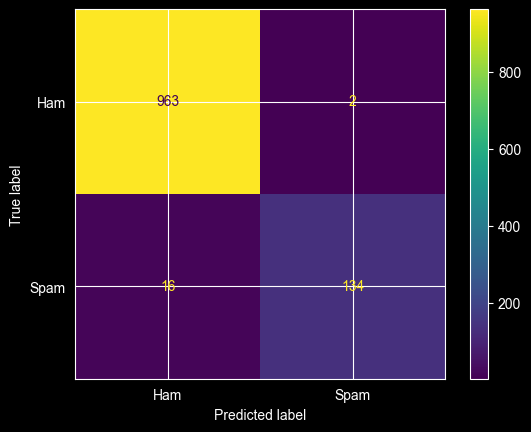

In [30]:
# Task 5 — train MultinomialNB, compute metrics, plot confusion matrix
model = MultinomialNB()
model.fit(X_train_vec, y_train)
y_pred = model.predict(X_test_vec)
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Ham', 'Spam']
)

disp.plot()
plt.show()

**Task 5 — Spam Model Metrics**

| Metric | Value |
|---|-------|
| Accuracy | 98.3% |
| Precision | 98.5% |
| Recall | 89.3% |
| F1-score | 93.7% |

**Answer 6:**
A false positive means a real message is incorrectly classified as spam, so an important message could be blocked or missed. A false negative means a spam message is classified as a normal message and reaches the user's inbox. In this case, I would prioritize precision because avoiding false positives helps prevent legitimate messages from being incorrectly marked as spam. Our model has a precision of 98.53%, meaning most messages predicted as spam are actually spam.

---

## 4. Task A: Word Interpretation (Spam)

*Concepts/functions you may find useful:* `model.feature_log_prob_`, `np.argsort(...)`

**Tasks**
7. Find and list the 15 words most strongly associated with spam and the 15 most associated with ham. Do these match your intuition?
8. Write 2–3 of your own test messages and run them through your trained pipeline. Do the predictions match what you expected?

In [31]:
# Task 7 — extract top spam words and top ham words from feature_log_prob_
feature_names = vectorizer.get_feature_names_out()
log_probs = model.feature_log_prob_
spam_scores = log_probs[1] - log_probs[0]
spam_indices = np.argsort(spam_scores)[-15:][::-1]
spam_words = feature_names[spam_indices]
print("Top 15 Spam-associated words:")
print(spam_words)
ham_indices = np.argsort(spam_scores)[:15]
ham_words = feature_names[ham_indices]
print("\nTop 15 Ham-associated words:")
print(ham_words)

Top 15 Spam-associated words:
['claim' 'prize' 'uk' '150p' 'tone' '18' 'guaranteed' 'cs' '500' '1000'
 '100' '150ppm' 'awarded' 'ringtone' 'www']

Top 15 Ham-associated words:
['gt' 'lt' 'he' 'lor' 'she' 'da' 'ì_' 'later' 'too' 'say' 'amp' 'ask'
 'said' 'doing' 'my']


**Answer 7:**
_(your answer here)_

In [32]:
# Task 8 — test your own messages
my_messages = [
    "Congratulations! You have won a free prize. Claim your reward now!",
    "Hey, are you coming to class tomorrow?",
    "URGENT! You have won $5000. Call now to claim your cash prize!"
]
my_messages_clean = [msg.lower() for msg in my_messages]
my_messages_vec = vectorizer.transform(my_messages_clean)
my_predictions = model.predict(my_messages_vec)
for message, prediction in zip(my_messages, my_predictions):
    label = "Spam" if prediction == 1 else "Ham"
    print("Message:", message)
    print("Prediction:", label)
    print()


Message: Congratulations! You have won a free prize. Claim your reward now!
Prediction: Spam

Message: Hey, are you coming to class tomorrow?
Prediction: Ham

Message: URGENT! You have won $5000. Call now to claim your cash prize!
Prediction: Spam



**Answer 8:**
I tested the model on three new messages, including two spam-like messages and one normal message. The model classified the two spam-like messages as Spam and the normal message as Ham, which matched my expectations.

---

## 5. Task A: Kaggle Notebook Submission

Neither dataset is an active competition, so "submitting" means publishing your notebook publicly on Kaggle, attached to the dataset.

**Tasks**
9. Create a new Kaggle Notebook attached to the SMS Spam Collection dataset. Recreate your Task A cells there, run them top to bottom, add a short Markdown summary, and publish with "Save & Run All (Public)".
10. Record the public notebook URL below.

**Task A Kaggle Notebook URL:**
https://www.kaggle.com/code/faryalgul786/spam-detection?scriptVersionId=353010933

---

## 6. Task B: Text Cleaning & Vectorization (Sentiment)

Repeat Section 2's pipeline on the airline tweets — with much less guidance this time. Tweets contain @mentions, links, and hashtags that SMS messages didn't.

**Tasks**
11. Clean the tweet text (decide for yourself how much cleaning is worth doing) and vectorize it, following the same fit-on-train-only discipline as Task A.
12. Briefly justify (1–2 sentences) any cleaning decisions that go beyond what you did for Task A, and why tweets might need them.

In [34]:
# Task 11 — clean and vectorize the sentiment data (your own approach)
sent['text'] = sent['text'].str.lower()
sent['text'] = sent['text'].str.replace(r'@\w+', '', regex=True)
sent['text'] = sent['text'].str.replace(r'http\S+|www\S+', '', regex=True)
sent['text'] = sent['text'].str.replace('#', '', regex=False)
sent['label'] = sent['airline_sentiment'].map({
    'negative': 0,
    'positive': 1
})
X_sent = sent['text']
y_sent = sent['label']
X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_sent,
    y_sent,
    test_size=0.2,
    random_state=42
)
sent_vectorizer = CountVectorizer()

X_train_s_vec = sent_vectorizer.fit_transform(X_train_s)
X_test_s_vec = sent_vectorizer.transform(X_test_s)
print("Vocabulary size:", len(sent_vectorizer.get_feature_names_out()))

Vocabulary size: 10110


**Answer 12:**
Tweets contain @mentions, URLs, and hashtags that are not usually useful for identifying sentiment. Therefore, I removed mentions and URLs and removed the # symbol while keeping the hashtag word, so the model can focus more on meaningful text.

---

## 7. Task B: Naive Bayes Model & Evaluation (Sentiment)

**Tasks**
13. Train a `MultinomialNB` model on the vectorized tweet data. Compute accuracy, precision, recall, and F1-score, and plot the confusion matrix.
14. Compare these metrics to Task A's. Did Naive Bayes do better or worse on sentiment than on spam? Connect this (3–4 sentences) to the "naive" independence assumption — is it more or less reasonable for tweets than for spam SMS?

Accuracy : 0.9138155045474231
Precision: 0.9161073825503355
Recall   : 0.610738255033557
F1-score : 0.7328859060402685


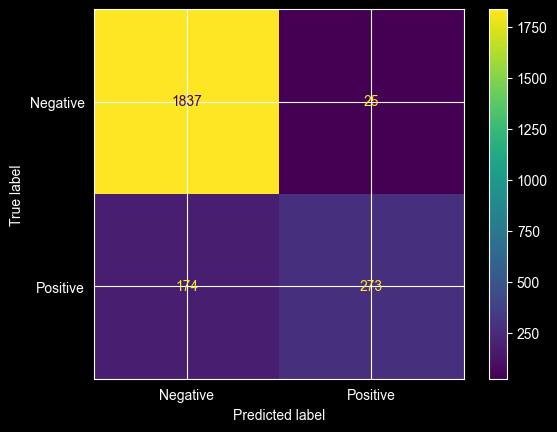

In [35]:
# Task 13 — train MultinomialNB, compute metrics, plot confusion matrix
sent_model = MultinomialNB()
sent_model.fit(X_train_s_vec, y_train_s)
y_pred_s = sent_model.predict(X_test_s_vec)
accuracy_s = accuracy_score(y_test_s, y_pred_s)
precision_s = precision_score(y_test_s, y_pred_s)
recall_s = recall_score(y_test_s, y_pred_s)
f1_s = f1_score(y_test_s, y_pred_s)
print("Accuracy :", accuracy_s)
print("Precision:", precision_s)
print("Recall   :", recall_s)
print("F1-score :", f1_s)
cm_s = confusion_matrix(y_test_s, y_pred_s)
disp_s = ConfusionMatrixDisplay(
    confusion_matrix=cm_s,
    display_labels=['Negative', 'Positive']
)

disp_s.plot()
plt.show()

**Task 13 — Sentiment Model Metrics**

| Metric | Value |
|---|-------|
| Accuracy | 91.3% |
| Precision | 91.6% |
| Recall | 61.0% |
| F1-score | 73.2% |

**Answer 14:**
Naive Bayes performed better on the spam classification task than on the sentiment classification task, as all four evaluation metrics were higher for spam. The independence assumption is more reasonable for spam SMS because individual words such as “free”, “prize”, or “winner” can be strong indicators of spam. For tweets, sentiment often depends more on the combination and context of words, such as negation and word relationships, making the independence assumption less suitable. This may explain the lower recall and F1-score for sentiment classification.

---

## 8. Task B: Kaggle Notebook Submission

**Tasks**
15. Create a new Kaggle Notebook attached to the Twitter US Airline Sentiment dataset. Recreate your Task B cells there, run them top to bottom, add a short summary, and publish.
16. Record the public notebook URL below.

**Task B Kaggle Notebook URL:**
https://www.kaggle.com/code/faryalgul786/sentimental-analysis?scriptVersionId=353018296

---

## 9. Cross-Task Comparison & vs. Logistic Regression

*Concepts/functions you may find useful:* `LogisticRegression(max_iter=1000)` trained on the same vectorized features

**Tasks**
17. Build a table comparing Naive Bayes on Task A vs. Task B (accuracy, precision, recall, F1).
18. Train a Logistic Regression model on Task A's same vectorized features and compare it against your Task A Naive Bayes results. Which model wins, and does that match what you'd expect?

**Task 17 — Task A vs. Task B (Naive Bayes)**

| Metric | Task A (Spam) | Task B (Sentiment) |
|---|---------------|--------------------|
| Accuracy | 98.39%        | 91.38%             |
| Precision | 98.53%        | 91.61%             |
| Recall | 89.33%        | 61.07%             |
| F1-score | 93.71%        | 73.29%             |

In [36]:
# Task 18 — train Logistic Regression on Task A's vectorized features
lr_model = LogisticRegression(max_iter=1000)
lr_model.fit(X_train_vec, y_train)
lr_pred = lr_model.predict(X_test_vec)
lr_accuracy = accuracy_score(y_test, lr_pred)
lr_precision = precision_score(y_test, lr_pred)
lr_recall = recall_score(y_test, lr_pred)
lr_f1 = f1_score(y_test, lr_pred)
print("Logistic Regression")
print("Accuracy :", lr_accuracy)
print("Precision:", lr_precision)
print("Recall   :", lr_recall)
print("F1-score :", lr_f1)
lr_comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Naive Bayes': [accuracy, precision, recall, f1],
    'Logistic Regression': [lr_accuracy, lr_precision, lr_recall, lr_f1]
})
print(lr_comparison)

Logistic Regression
Accuracy : 0.9775784753363229
Precision: 0.9921259842519685
Recall   : 0.84
F1-score : 0.9097472924187726
      Metric  Naive Bayes  Logistic Regression
0   Accuracy     0.983857             0.977578
1  Precision     0.985294             0.992126
2     Recall     0.893333             0.840000
3   F1-score     0.937063             0.909747


**Task 18 — Naive Bayes vs. Logistic Regression (Task A)**

| Metric | Naive Bayes | Logistic Regression |
|---|-------------|---------------------|
| Accuracy | 98.3%       | 97.7%               |
| Precision | 98.5%       | 99.2%               |
| Recall | 89.3%       | 84.0%               |
| F1-score | 93.7%       | 90.9%               |

**Answer 18 (which wins, and does it match expectations):**
Naive Bayes performed better overall than Logistic Regression on the Task A spam classification, with higher accuracy, recall, and F1-score. Logistic Regression achieved slightly higher precision (99.21%) than Naive Bayes (98.53%), but Naive Bayes had higher accuracy (98.39%), recall (89.33%), and F1-score (93.71%). This result is reasonable because individual words can be strong indicators of spam, which suits the assumptions made by Naive Bayes.

---

## 10. Final Reflection & Conclusion

**Tasks**
19. Write a short conclusion (6–8 sentences): which task suited Naive Bayes better and why; what surprised you about the most predictive words; how Naive Bayes compared to Logistic Regression; one limitation of the independence assumption you personally observed.
20. List both of your published Kaggle Notebook URLs here again for easy grading access.

**Answer 19 — Conclusion:**
Naive Bayes suited the SMS Spam Classification task better than the Twitter Sentiment Classification task. It achieved higher accuracy, precision, recall, and F1-score on the spam dataset. I was surprised that some individual words could be strong indicators of spam, showing that certain words can help the model distinguish spam messages. On Task A, Naive Bayes performed slightly better overall than Logistic Regression, although Logistic Regression had a higher precision. The independence assumption worked well for spam classification because individual words can provide strong clues about whether a message is spam. However, for sentiment classification, the meaning of words can depend on their combination and context, so the independence assumption was a limitation I observed. Overall, Naive Bayes was more effective for the SMS spam task than for the Twitter sentiment task.

**Answer 20 — Kaggle Notebook Links:**
- Task A:  https://www.kaggle.com/code/faryalgul786/spam-detection?scriptVersionId=353010933
- Task B: https://www.kaggle.com/code/faryalgul786/sentimental-analysis?scriptVersionId=353018296

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, both datasets)
- [ ] Section 1 — Problem Definition & Dataset Exploration (both datasets, neutral tweets dropped)
- [ ] Section 2 — Task A Cleaning & Vectorization (fit on training data only)
- [ ] Section 3 — Task A Model & Evaluation (all four metrics + confusion matrix + precision/recall argument)
- [ ] Section 4 — Task A Word Interpretation (top words + your own test messages)
- [ ] Section 5 — Task A Kaggle Notebook published and linked
- [ ] Section 6 — Task B Cleaning & Vectorization (cleaning choices justified)
- [ ] Section 7 — Task B Model & Evaluation (all four metrics + independence-assumption discussion)
- [ ] Section 8 — Task B Kaggle Notebook published and linked
- [ ] Section 9 — Cross-Task Comparison & vs. Logistic Regression
- [ ] Section 10 — Final Reflection & Conclusion (both Kaggle links listed again)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted